In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
from Meta_learning import MetaLearner
import Meta_loss_functions as mlf

In [4]:
class Generator(nn.Module):
    def __init__(self, num_classes, n_per_class, seq_len, vocab_size=26):
        super().__init__()
        self.num_classes = num_classes
        self.n_per_class = n_per_class
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.total = num_classes * n_per_class
        
        init_data = torch.rand(self.total, seq_len, vocab_size)
        init_data = init_data / init_data.sum(dim=-1, keepdim=True)
        self.data = nn.Parameter(init_data)
    
    def forward(self, z=None, y=None):
        x = F.softmax(self.data, dim=-1)
        return x
    
    def visualize(self, x=None, y=None, n_visualize=5, save_path=None):
        if x is None or y is None:
            x, y = self.generate_dataset()

        indices = x.argmax(dim=-1).detach().cpu().numpy()
        y = y.detach().cpu().numpy()

        letters = [chr(ord('A') + i) for i in range(self.vocab_size)]
        
        cols_per_row = 3
        n_visualize = min(n_visualize, self.n_per_class)

        num_rows = (self.num_classes + cols_per_row - 1) // cols_per_row

        fig_width = n_visualize * 1.2
        fig_height = num_rows * 2.5
        
        fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(fig_width, fig_height))
        
        if num_rows == 1:
            axes = axes.reshape(1, -1)
        if cols_per_row == 1:
            axes = axes.reshape(-1, 1)
        
        for class_idx in range(self.num_classes):
            row = class_idx // cols_per_row
            col = class_idx % cols_per_row
            
            ax = axes[row, col]
            ax.axis('off')

            ax.set_title(f'Class {class_idx}', fontsize=12, fontweight='bold')

            class_indices = np.where(y == class_idx)[0][:n_visualize]
            
            if len(class_indices) == 0:
                ax.text(0.5, 0.5, 'No samples', ha='center', va='center', fontsize=10)
                continue

            for i, idx in enumerate(class_indices):
                seq = indices[idx]
                seq_str = ''.join([letters[c] for c in seq])

                y_pos = 1 - (i + 0.5) / (len(class_indices) + 0.5)

                bg_color = '#f0f0f0' if i % 2 == 0 else 'white'
                
                ax.text(0.5, y_pos, seq_str, fontsize=9, family='monospace',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor=bg_color, edgecolor='gray', linewidth=0.5))
            
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)

            ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', linewidth=1.5))

        for row in range(num_rows):
            for col in range(cols_per_row):
                class_idx = row * cols_per_row + col
                if class_idx >= self.num_classes:
                    axes[row, col].axis('off')
                    axes[row, col].add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='none'))
        
        plt.suptitle(f"Generated Sequences", fontsize=14)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

In [5]:
class RNN(nn.Module):
    def __init__(self, num_classes, vocab_size=26, hidden_dim=32, num_layers=2):
        super().__init__()
        
        self.rnn = nn.RNN(
            input_size=vocab_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        last_out = out[:, -1, :]
        return self.fc(last_out)

/Users/annanovoksonova/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/module.py:938: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  param_grad = param.grad


step: 2975, meta_loss: -0.0233, accuracy: 100.00%


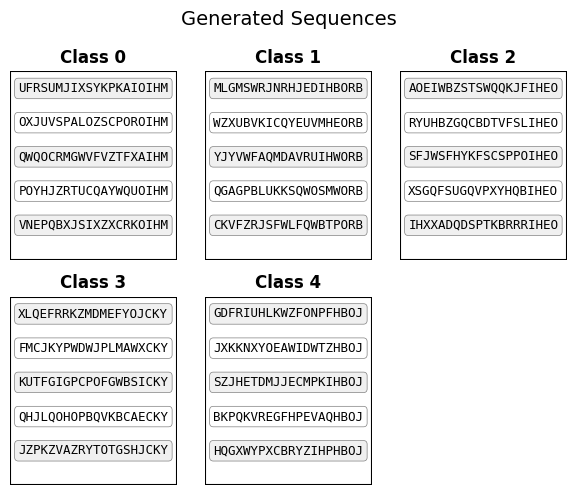

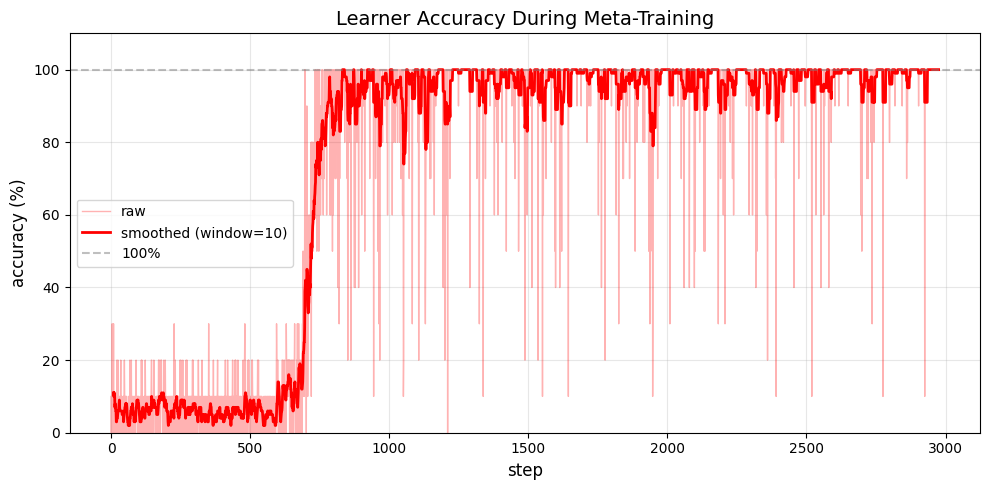

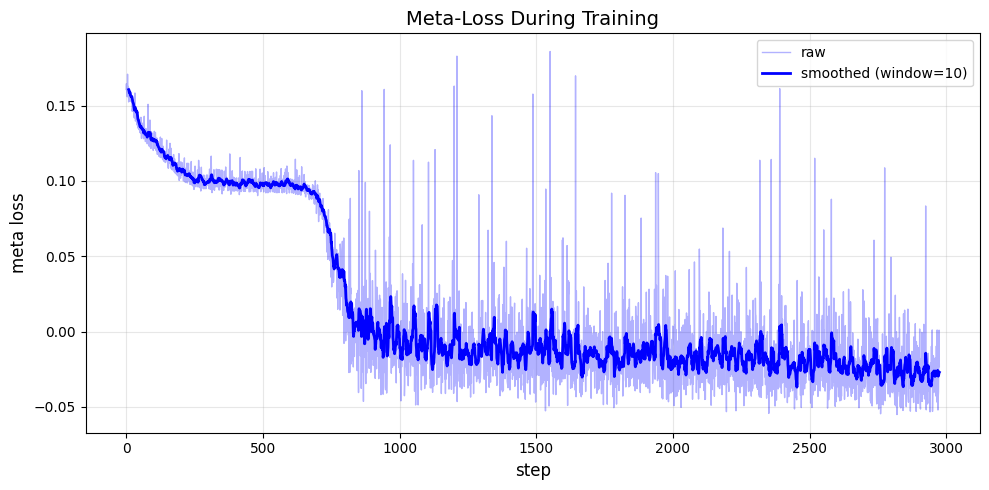

In [6]:
generator = Generator(num_classes=5, n_per_class=10, seq_len=20)

meta = MetaLearner(
    generator=generator,
    learner_class=RNN,
    meta_loss_fn=mlf.meta_loss_mse,
    regularization_fn=mlf.regularizer_class_diversity,
    reg_parameter=0.1,
    num_classes=5,
    n_per_class=10,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=10, 
    n_visualize=5,
    stop_after_consecutive_100=50
)

meta.train(steps=3000, visualize_every=0)
meta.plot_accuracy()
meta.plot_meta_loss()

In [7]:
num_rnns = 100
num_classes=5
n_per_class=20
y = torch.arange(num_classes).repeat_interleave(n_per_class)
x = generator.forward().detach()

results = {
    'original': [],
    'reversed': []
}

for rnn_idx in range(num_rnns):    
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    rnn = RNN(num_classes=5)
    optimizer = torch.optim.Adam(rnn.parameters(), lr=0.01)

    for epoch in range(30):
        optimizer.zero_grad()
        logits = rnn(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    rnn.eval()
    with torch.no_grad():
        logits = rnn(x_test)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    results['original'].append(acc_original)

    x_reversed = torch.flip(x_test, dims=[1])

    with torch.no_grad():
        logits_rev = rnn(x_reversed)
        preds_rev = logits_rev.argmax(dim=1)
        acc_reversed = (preds_rev == y_test).float().mean().item() * 100
    results['reversed'].append(acc_reversed)
    rnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])
mean_reversed = np.mean(results['reversed'])
std_reversed = np.std(results['reversed'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")
print(f"{'Reversed':<15} {mean_reversed:.2f} ± {std_reversed:.2f}")

Data type       Accuracy (%)        
--------------------------------------------------
Original        100.00 ± 0.00                
Reversed        32.40 ± 14.08


In [8]:
num_rnns = 100
num_classes=5
n_per_class=20
y = torch.arange(num_classes).repeat_interleave(n_per_class)
x = generator.forward().detach()

results = {
    'original': [],
    'reversed': []
}

for rnn_idx in range(num_rnns): 
    x_reversed = torch.flip(x, dims=[1])   
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x_reversed[train_idx]
    y_train = y[train_idx]
    x_test = x_reversed[test_idx]
    y_test = y[test_idx]
    
    rnn = RNN(num_classes=5)
    optimizer = torch.optim.Adam(rnn.parameters(), lr=0.01)

    for epoch in range(30):
        optimizer.zero_grad()
        logits = rnn(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    rnn.eval()
    with torch.no_grad():
        logits = rnn(x_test)
        preds = logits.argmax(dim=1)
        acc_reversed = (preds == y_test).float().mean().item() * 100
    results['reversed'].append(acc_reversed)

    with torch.no_grad():
        logits_rev = rnn(x[test_idx])
        preds_rev = logits_rev.argmax(dim=1)
        acc_original = (preds_rev == y_test).float().mean().item() * 100
    results['original'].append(acc_original)
    rnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])
mean_reversed = np.mean(results['reversed'])
std_reversed = np.std(results['reversed'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Reversed':<15} {mean_reversed:.2f} ± {std_reversed:.2f}")
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")

Data type       Accuracy (%)        
--------------------------------------------------
Reversed        42.20 ± 27.91
Original        29.10 ± 17.33                
